## III.3 An Improved SPINN Framework for Material Characterization

### Allen-Cahn (ac)

In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt 
import scienceplots
plt.style.use(['science', 'grid'])
from pathlib import Path

from phd.models.allen_cahn import (
    train, test_data, plot_results, 
    save_run_data, load_run, save_fields, load_fields, get_run_dir
)
from phd.config import load_config, copy_config, apply_overrides, print_config
from phd.plot import PlottingConfig, get_current_config, book_config, book_compact_config, A4_config
from phd.io import save_df_to_latex

# --- Settings ---
save_fig = True
if save_fig:
    mpl.rcParams['pgf.texsystem'] = 'pdflatex'

# Initialize plotting configuration
book_config.set_as_current()

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



## Fourier Features

Fourier features help in learning high-frequency components.

### 1-Run/load model

In [2]:
# === Fourier Features Experiments ===
# Run configurations to train (empty list = load all from disk)
configs_to_run_FF = []  # e.g. ["pinn", "spinn", "spinn_mod"]

# Load base config once
base_cfg = load_config("allen_cahn")

# Modify base settings for FF experiments
base_cfg.model.fourier_features.n_features = 128
base_cfg.model.fourier_features.sigma = 10
base_cfg.model.architecture.activations = "sin"
base_cfg.model.architecture.rank = 32
base_cfg.training.num_domain = 22500  # 150^2
base_cfg.training.n_iter = 100000
base_cfg.training.lr = 1e-5
base_cfg.training.lr_decay = ["warmup cosine", 1e-5, 1e-3, 1000, 100000, 1e-5]
base_cfg.seed = 0

# Define model variants (only the differences from base)
model_variants = {
    "pinn": {"model.net_type": "PINN", "model.fourier_features.n_features": 256},
    "spinn": {"model.net_type": "SPINN"},
    "spinn_mod": {"model.net_type": "SPINN", "model.architecture.mlp_type": "modified-mlp", "model.fourier_features.n_features": 64},
}

all_config_names_FF = list(model_variants.keys())
all_data_FF = {}

# === Train or Load each configuration ===
for config_name in all_config_names_FF:
    for ff_enabled in [False, True]:
        suffix = "_FF" if ff_enabled else ""
        run_name = config_name + suffix
        
        should_train = config_name in configs_to_run_FF
        
        if should_train:
            # Create a fresh copy and apply variant settings
            cfg = copy_config(base_cfg)
            cfg.model.fourier_features.enabled = ff_enabled
            apply_overrides(cfg, model_variants[config_name])
            
            print(f"Training: {run_name}")
            results = train(cfg)
            
            # Save using problem-specific wrapper
            save_run_data(results, run_name=run_name)
            
            # Store in memory (excluding model for memory efficiency)
            results.pop("model", None)
            all_data_FF[run_name] = results
        else:
            # Load existing run
            try:
                print(f"Loading: {run_name}")
                all_data_FF[run_name] = load_run(run_name)
            except FileNotFoundError:
                print(f"Warning: {run_name} not found")

# Text labels for plotting
config_text_dict = {
    "pinn": "PINN",
    "pinn_FF": "PINN + FF",
    "spinn": "SPINN",
    "spinn_FF": "SPINN + FF",
    "spinn_mod": "SPINN-mod",
    "spinn_mod_FF": "SPINN-mod + FF",
}

Loading: pinn


W0209 10:48:18.779810   64842 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0209 10:48:18.784228   64710 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


Loading: pinn_FF
Loading: spinn
Loading: spinn_FF
Loading: spinn_mod
Loading: spinn_mod_FF


### 2-Plot results

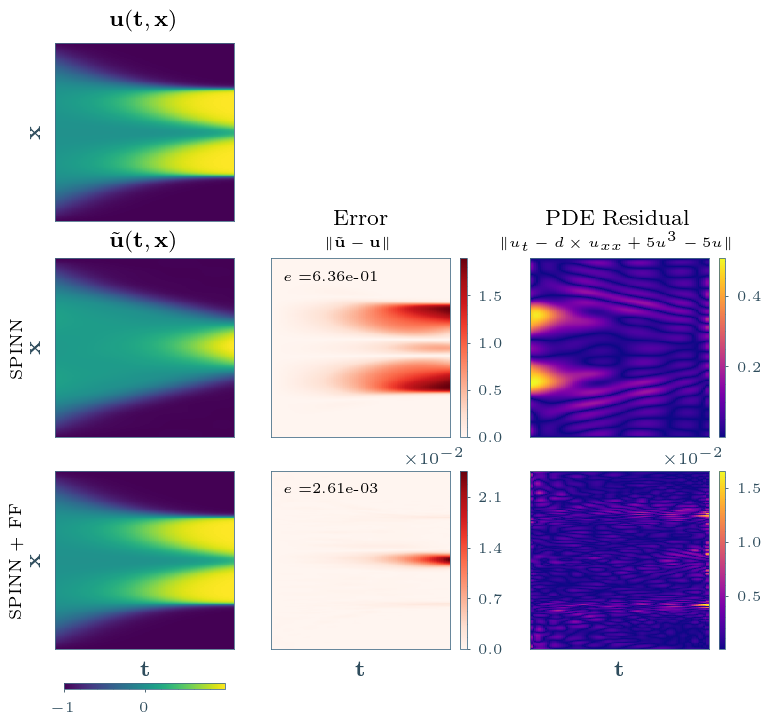

In [7]:
import matplotlib.transforms as mtransforms
from matplotlib import ticker

config_to_plot_FF = ["spinn"]  # e.g. ["pinn", "spinn", "spinn_mod"]

# Plotting configuration
book_config.set_as_current()
page_width = get_current_config().page_width
min_font_size = get_current_config().min_font_size

# Load test data
cfg_test = load_config("allen_cahn")
X_input, xx, tt, u_true = test_data(cfg_test)
    
def fields_from_config(config_keys, all_data, config_text_dict, u_true=u_true):
    """Extract fields for plotting from loaded data."""
    u_pred_all, u_diff_all, pde_loss_all, rows_title = [], [], [], []
    
    for key in config_keys:
        if key not in all_data: 
            continue
        last_step = max(int(k) for k in all_data[key]["fields"].keys())
        e = all_data[key]["fields"][last_step]
        u_pred_all.append(e["u_pred"])
        u_diff_all.append(e["u_pred"] - u_true)
        pde_loss_all.append(e["pde_loss"])
        rows_title.append((e.get("l2_error", 1e9), config_text_dict.get(key, key)))

    if not rows_title:
        print(f"Warning: No data found for keys: {config_keys}")
        return [u_true] if u_true is not None else [], [], [], []
    
    order = sorted(range(len(rows_title)), key=lambda i: rows_title[i][0], reverse=True)
    u_pred_all = [u_pred_all[i] for i in order]
    u_diff_all = [u_diff_all[i] for i in order]
    pde_loss_all = [pde_loss_all[i] for i in order]
    rows_title = [rows_title[i][1] for i in order]
    u_pred_all = [u_true] + u_pred_all
    return u_pred_all, u_diff_all, pde_loss_all, rows_title

config_to_plot_FF_and_suffix = [c + suffix for c in config_to_plot_FF for suffix in ("", "_FF")]
u_pred_all, u_diff_all, pde_loss_all, rows_title = fields_from_config(
    config_to_plot_FF_and_suffix, all_data_FF, config_text_dict
)
n_rows = len(rows_title) 

if n_rows > 0:
    fields_FF = {
        "Solution": {
            "data": u_pred_all,
            "title": r"$\tilde{\mathbf{u}}(\mathbf{t},\mathbf{x})$",
            "cmap": "viridis",
            "abs": False,
        },
        "Error": {
            "data": u_diff_all,
            "title": f"Error\n\\fontsize{{{min_font_size}}}{{{min_font_size}}} $\\|\\tilde{{\\mathbf{{u}}}} - \\mathbf{{u}}\\|$",
            "cmap": "Reds",
            "abs": True,
        },
        "PDE Residual": {
            "data": pde_loss_all,
            "title": "PDE Residual\n" + f"\\fontsize{{{min_font_size}}}{{{min_font_size}}} $\\|u_t - d \\times u_{{xx}} + 5u^3 - 5u\\|$",
            "cmap": "plasma",
            "abs": True,
        },
    }

    fig, ax = plt.subplots(1+n_rows, 3, figsize=(page_width, page_width/3.6*(n_rows+1)), dpi=200)
    plot_results(fig, ax, fields_FF, tt, xx, rows_title)
    plt.show()

    # Save figure
    if save_fig:
        figure_folder = Path("images")
        fig.savefig(figure_folder / "allen_cahn_fourier_features_comparison.png", bbox_inches="tight")
        fig.savefig(figure_folder / "pdf" / "allen_cahn_fourier_features_comparison.pdf", bbox_inches="tight")
        
        print(f"Figure saved to {figure_folder / 'allen_cahn_fourier_features_comparison.png'} and {figure_folder / 'pdf' / 'allen_cahn_fourier_features_comparison.pdf'}")
else:
    print("No data to plot. Run training first or check that results exist.")

Figure height: 90.0 mm
Figure saved to images/ac_baseline_comparison.png and images/pdf/ac_baseline_comparison.pdf


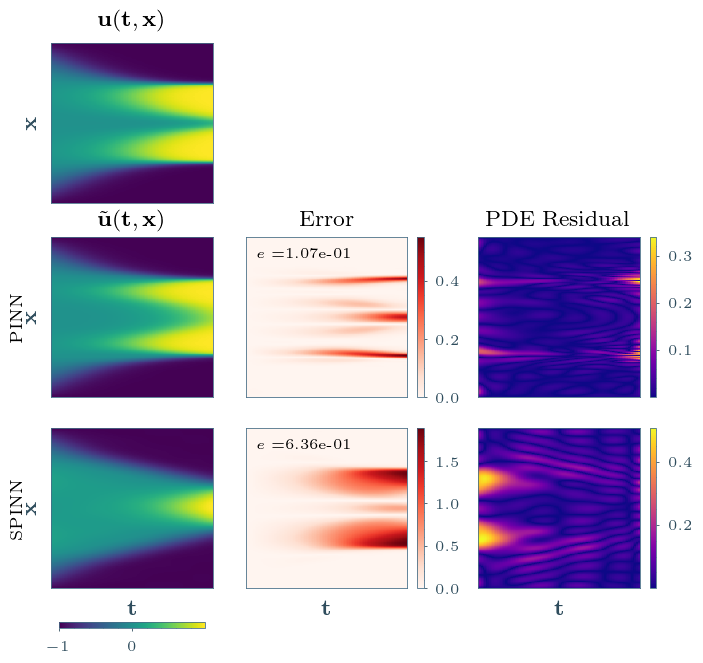

In [9]:
# === Combined FF + SA Comparison Plot ===
book_config.set_as_current()
page_width = get_current_config().page_width
min_font_size = get_current_config().min_font_size

# Combine all data for comparison
all_data = all_data_FF
config_to_plot_FF_SA = ["pinn", "spinn"]

config_text_dict_FF_SA = {
    **config_text_dict,
    "pinn": "PINN",
    "spinn": "SPINN",
}

u_pred_all, u_diff_all, pde_loss_all, rows_title = fields_from_config(
    config_to_plot_FF_SA, all_data, config_text_dict_FF_SA, 
)
n_rows = len(rows_title) 

fields_FF_SA = {
    "Solution": {
        "data": u_pred_all,
        "title": r"$\tilde{\mathbf{u}}(\mathbf{t},\mathbf{x})$",
        "cmap": "viridis",
        "abs": False,
    },
    "Error": {
        "data": u_diff_all,
        "title": f"Error",#\n\\fontsize{{{min_font_size}}}{{{min_font_size}}} $\\|\\tilde{{\\mathbf{{u}}}} - \\mathbf{{u}}\\|$",
        "cmap": "Reds",
        "abs": True,
    },
    "PDE Residual": {
        "data": pde_loss_all,
        "title": "PDE Residual",#\n" + f"\\fontsize{{{min_font_size}}}{{{min_font_size}}} $\\|u_t - d \\times u_{{xx}} + 5u^3 - 5u\\|$",
        "cmap": "plasma",
        "abs": True,
    },
}

fig_width = page_width * 0.9
fig_height = min(fig_width / 3.6 * (n_rows + 1), 160 / 25.4)  # max height of 160mm
print(f"Figure height: {fig_height * 25.4:.1f} mm")

fig, ax = plt.subplots(1 + n_rows, 3, figsize=(fig_width, fig_height), dpi=200)
fig, ax = plot_results(fig, ax, fields_FF_SA, tt, xx, rows_title)

if save_fig:
    figure_folder = Path("images")
    fig.savefig(figure_folder / "ac_baseline_comparison.png", bbox_inches="tight")
    fig.savefig(figure_folder / "pdf" / "ac_baseline_comparison.pdf", bbox_inches="tight")
    print(f"Figure saved to {figure_folder / 'ac_baseline_comparison.png'} and {figure_folder / 'pdf' / 'ac_baseline_comparison.pdf'}")

In [10]:
import pandas as pd
from IPython.display import display

def build_results_df(all_data, config_text_dict=None, append_config=False):
    """Build a summary DataFrame from all_data dict."""
    rows = []
    for key in sorted(all_data.keys()):
        entry = all_data[key]
        losshistory = entry.get("losshistory", {})
        l2 = losshistory.metrics_test[-1][0]
        mean_pde = losshistory.loss_test[-1][0]
        iters_per_s = entry.get("iterations_per_sec", np.nan)
        elapsed = entry.get("elapsed_time", np.nan)
        name = config_text_dict.get(key, key) if config_text_dict is not None else key

        rows.append({
            "model_name": name,
            "l2_error": float(l2) if np.isfinite(l2) else np.nan,
            "mean_pde_residual": float(mean_pde) if np.isfinite(mean_pde) else np.nan,
            "iterations_per_sec": float(iters_per_s) if np.isfinite(iters_per_s) else np.nan,
            "elapsed_time_min": float(elapsed)/60 if np.isfinite(elapsed) else np.nan,
        })

        if append_config:
            config = entry.get("config", {})
            for k, v in config.items():
                if k not in rows[-1]:
                    rows[-1][k] = v

    df = pd.DataFrame(rows)
    df = df.sort_values("l2_error", ascending=False).reset_index(drop=True)
    return df

# Build and display results DataFrame
df_results_FF = build_results_df(all_data_FF, config_text_dict=config_text_dict)

display(
    df_results_FF.style
    .background_gradient(subset=["l2_error"], cmap="Greens_r")
    .format("{:.2e}", subset=["l2_error", "mean_pde_residual"])
    .format("{:.2f}", subset=["iterations_per_sec"])
    .format("{:.2f}", subset=["elapsed_time_min"])
    .set_properties(subset=["model_name"], **{"text-align": "left"})
)

# Optionally save to LaTeX
# table_folder = results_base_dir / "tables" / "FourierFeatures"
# table_folder.mkdir(parents=True, exist_ok=True)

# with open(table_folder / "results.tex", 'w') as f:
#     f.write(df_results_FF.to_latex(index=False, float_format="%.2e", column_format="lcccc"))

,model_name,l2_error,mean_pde_residual,iterations_per_sec,elapsed_time_min
0,SPINN-mod,6.34e-01,1.08e-02,nan,nan
1,SPINN,6.34e-01,1.08e-02,nan,nan
2,PINN,1.08e-01,1.07e-03,nan,nan
3,SPINN-mod + FF,3.23e-03,2.53e-06,nan,nan
4,SPINN + FF,3.00e-03,2.45e-06,nan,nan
5,PINN + FF,1.35e-03,2.00e-06,nan,nan


## Self-Adaptive Attention (SA)

Self-adaptive attention mechanisms weight the PDE loss in some regions.

In [4]:
# === Self-Attention Experiments ===
from phd.models.allen_cahn import snapshot_fields

# Run configurations to train (empty list = load all from disk)
configs_to_run_SA = []  # e.g. ["pinn_SA", "spinn_SA", "spinn_mod_SA", "weight_vis"]

# Load base config and modify for SA experiments
base_cfg_SA = load_config("allen_cahn")
base_cfg_SA.model.fourier_features.enabled = True
base_cfg_SA.model.fourier_features.n_features = 128
base_cfg_SA.model.fourier_features.sigma = 10
base_cfg_SA.model.net_type = "SPINN"
base_cfg_SA.model.architecture.activations = "sin"
base_cfg_SA.model.architecture.rank = 64
base_cfg_SA.training.num_domain = 22500
base_cfg_SA.training.n_iter = 100000
base_cfg_SA.training.lr = 1e-5
base_cfg_SA.training.lr_decay = ["warmup cosine", 1e-5, 1e-3, 1000, 100000, 1e-5]
base_cfg_SA.training.self_attention.enabled = True
base_cfg_SA.seed = 0

# Define SA model variants (only the differences from base)
model_variants_SA = {
    "pinn_SA": {"model.net_type": "PINN", "model.fourier_features.n_features": 256},
    "spinn_SA": {"model.net_type": "SPINN"},
    "spinn_mod_SA": {"model.net_type": "SPINN", "model.architecture.mlp_type": "modified-mlp"},
    "weight_vis": {"training.lr": 1e-3, "training.lr_decay": ["warmup cosine", 1e-3, 1e-3, 3000, 50000, 1e-5]},
}

all_config_names_SA = list(model_variants_SA.keys())
all_data_SA = {}
iters_pde_w = [500, 2500, 47000]  # Special iterations for weight visualization

# === Train or Load each configuration ===
for config_name in all_config_names_SA:
    run_name = config_name
    should_train = config_name in configs_to_run_SA
    
    if should_train:
        cfg = copy_config(base_cfg_SA)
        apply_overrides(cfg, model_variants_SA[config_name])
        
        if config_name == "weight_vis":
            # Special handling for weight visualization: train in stages
            print(f"Training: {run_name} (staged for weight visualization)")
            
            run_dir = get_run_dir(run_name)
            run_dir.mkdir(parents=True, exist_ok=True)
            
            # Initialize model with 0 iterations
            cfg_init = copy_config(cfg)
            cfg_init.training.n_iter = 0
            init_results = train(cfg_init)
            model = init_results.pop('model')
            
            # Train in stages and capture fields at each stage
            fields = {}
            for i, iter_ in enumerate(iters_pde_w):
                model.train(iterations=iter_)
                total_iter = sum(iters_pde_w[:i+1])
                
                # Capture field snapshot using new function
                snapshot_fields(cfg, model, total_iter, fields)
                
                # Save fields to disk
                save_fields(run_dir, total_iter, fields[total_iter])
                
                l2_err = np.linalg.norm(fields[total_iter]["u_pred"] - fields[total_iter]["u_true"]) / np.linalg.norm(fields[total_iter]["u_true"])
                print(f"Iter {total_iter}: L2={l2_err:.3e}")
            
            results = {
                **init_results,
                "fields": fields,
                "config": cfg,
                "run_dir": str(run_dir),
            }
            all_data_SA[run_name] = results
            save_run_data(results, run_name=run_name)
        else:
            print(f"Training: {run_name}")
            results = train(cfg)
            save_run_data(results, run_name=run_name)
            results.pop("model", None)
            all_data_SA[run_name] = results
    else:
        try:
            print(f"Loading: {run_name}")
            all_data_SA[run_name] = load_run(run_name)
        except FileNotFoundError:
            print(f"Warning: {run_name} not found")

Loading: pinn_SA
Loading: spinn_SA
Loading: spinn_mod_SA
Loading: weight_vis


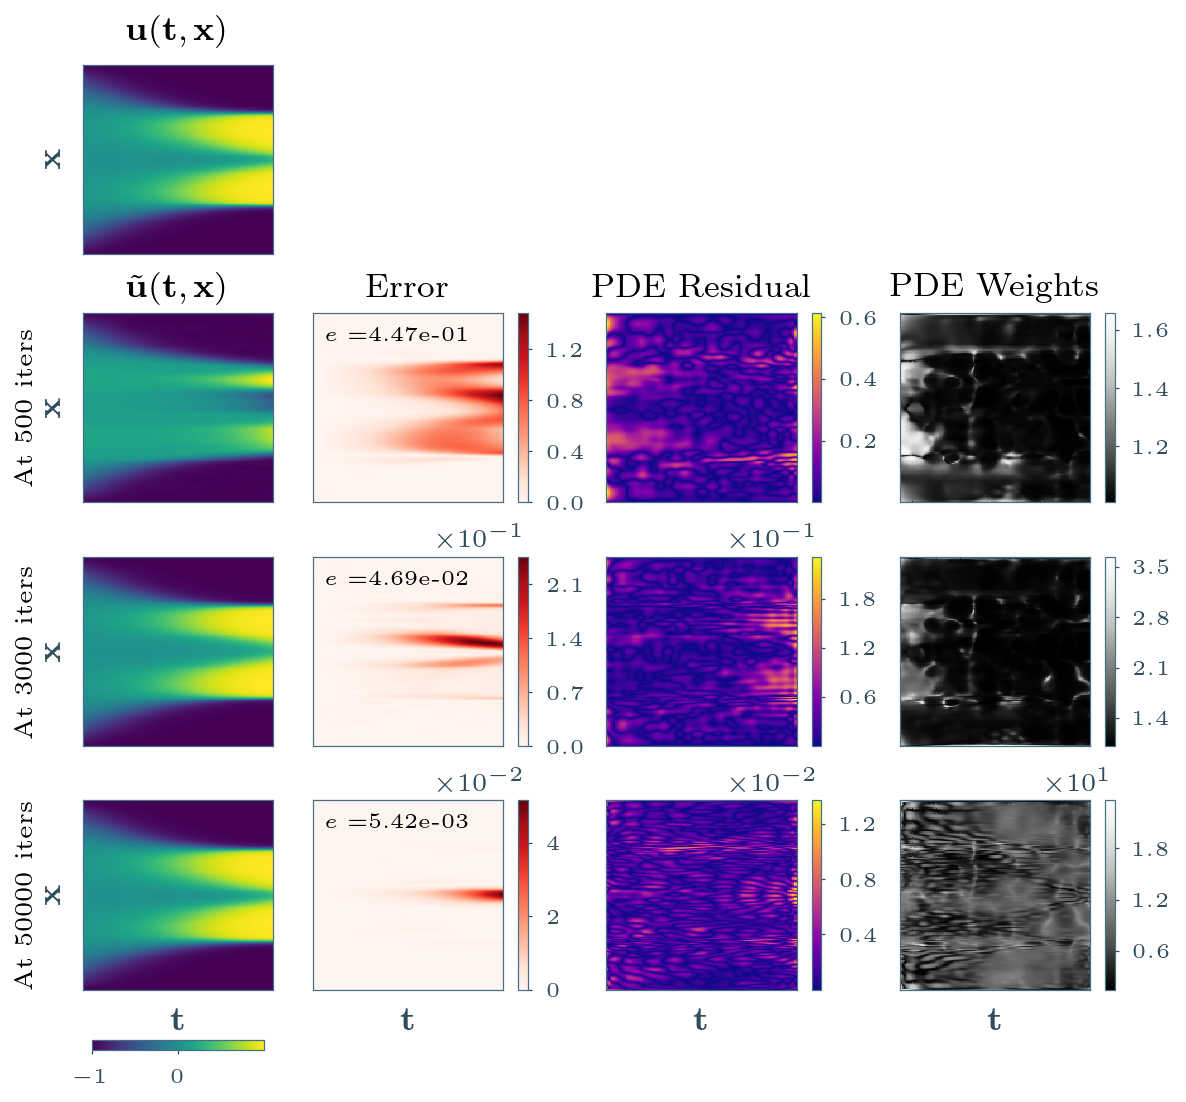

In [5]:
# === Plot Weight Visualization ===
book_config.set_as_current()
page_width = get_current_config().page_width
min_font_size = get_current_config().min_font_size

# Load test data grid
cfg_test = load_config("allen_cahn")
X_input, xx, tt, u_true = test_data(cfg_test)
X_train = [np.linspace(-1, 1, 150), np.linspace(0, 1, 150)]
x_train, t_train = np.meshgrid(X_train[0], X_train[1])

if "weight_vis" in all_data_SA and "fields" in all_data_SA["weight_vis"]:
    fields_data = all_data_SA["weight_vis"]["fields"]
    
    # Extract fields at each saved iteration
    u_pred_all, pde_loss_all, pde_weights_all = [], [], []
    for step in sorted(fields_data.keys()):
        snapshot = fields_data[step]
        u_pred_all.append(snapshot["u_pred"])
        pde_loss_all.append(snapshot["pde_loss"])
        if "pde_weights" in snapshot:
            pde_weights_all.append(snapshot["pde_weights"].reshape(x_train.shape).T)

    # Compute errors
    u_diff_all = [u - u_true for u in u_pred_all]
    rows_title = [f"At {step} iters" for step in sorted(fields_data.keys())]

    fields_SA_weight_vis = {
        "Solution": {
            "data": [u_true] + u_pred_all,
            "title": r"$\tilde{\mathbf{u}}(\mathbf{t},\mathbf{x})$",
            "cmap": None,
            "abs": False,
        },
        "Error": {
            "data": u_diff_all,
            "title": f"Error",
            "cmap": "Reds",
            "abs": True,
        },
        "PDE Residual": {
            "data": pde_loss_all,
            "title": f"PDE Residual",
            "cmap": "plasma",
            "abs": True,
        },
        "PDE Weights": {
            "data": pde_weights_all,
            "title": f"PDE Weights",
            "cmap": "Greys_r",
            "abs": False,
            "x_fields": x_train,
            "t_fields": t_train,
        },
    }

    fig, ax = plt.subplots(4, 4, figsize=(page_width, 0.85*page_width), dpi=300, gridspec_kw={'wspace': 0.35, 'hspace': 0.3})
    plot_results(fig, ax, fields_SA_weight_vis, tt, xx, rows_title, powerlimits=(-1, 1))

    save_fig = False
    if save_fig:
        figure_folder = Path("images")
        fig.savefig(figure_folder / "ac_weight_visualization.png", bbox_inches="tight")
        fig.savefig(figure_folder / "pdf" / "ac_weight_visualization.pdf", bbox_inches="tight")
        print(f"Figure saved to {figure_folder / 'ac_weight_visualization.png'} and {figure_folder / 'pdf' / 'ac_weight_visualization.pdf'}")
else:
    print("No weight_vis data found. Run SA experiments with 'weight_vis' in configs_to_run_SA first.")

Figure height: 120.0 mm


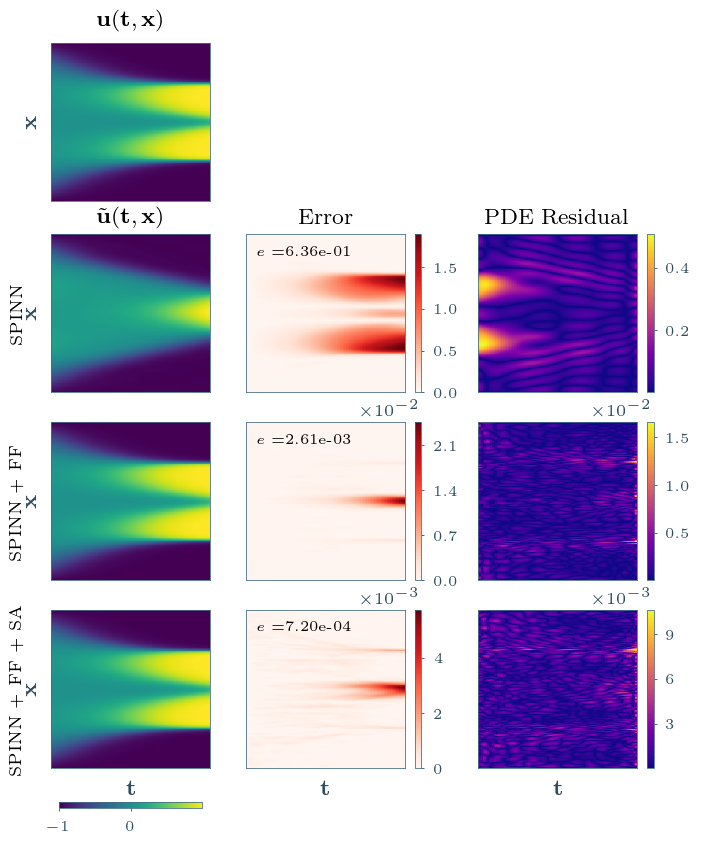

In [10]:
# === Combined FF + SA Comparison Plot ===
book_config.set_as_current()
page_width = get_current_config().page_width
min_font_size = get_current_config().min_font_size

# Combine all data for comparison
all_data = {**all_data_FF, **all_data_SA}
config_to_plot_FF_SA = ["spinn", "spinn_FF", "spinn_SA"] # "pinn_SA"

config_text_dict_FF_SA = {
    **config_text_dict,
    "pinn_SA": "PINN + FF + SA",
    "spinn_SA": "SPINN + FF + SA",
    "spinn_mod_SA": "SPINN-mod + FF + SA",
}

u_pred_all, u_diff_all, pde_loss_all, rows_title = fields_from_config(
    config_to_plot_FF_SA, all_data, config_text_dict_FF_SA, 
)
n_rows = len(rows_title) 

fields_FF_SA = {
    "Solution": {
        "data": u_pred_all,
        "title": r"$\tilde{\mathbf{u}}(\mathbf{t},\mathbf{x})$",
        "cmap": "viridis",
        "abs": False,
    },
    "Error": {
        "data": u_diff_all,
        "title": f"Error",#\n\\fontsize{{{min_font_size}}}{{{min_font_size}}} $\\|\\tilde{{\\mathbf{{u}}}} - \\mathbf{{u}}\\|$",
        "cmap": "Reds",
        "abs": True,
    },
    "PDE Residual": {
        "data": pde_loss_all,
        "title": "PDE Residual",#\n" + f"\\fontsize{{{min_font_size}}}{{{min_font_size}}} $\\|u_t - d \\times u_{{xx}} + 5u^3 - 5u\\|$",
        "cmap": "plasma",
        "abs": True,
    },
}

fig_width = page_width * 0.9
fig_height = min(fig_width / 3.6 * (n_rows + 1), 160 / 25.4)  # max height of 160mm
print(f"Figure height: {fig_height * 25.4:.1f} mm")

fig, ax = plt.subplots(1 + n_rows, 3, figsize=(fig_width, fig_height), dpi=200)
plot_results(fig, ax, fields_FF_SA, tt, xx, rows_title)

if save_fig:
    figure_folder = Path("images") 
    fig.savefig(figure_folder / "ac_ff_sa_comparison.png", bbox_inches="tight")
    fig.savefig(figure_folder / "pdf" / "ac_ff_sa_comparison.pdf", bbox_inches="tight")
    print(f"Figure saved to {figure_folder / 'ac_ff_sa_comparison.png'} and {figure_folder / 'pdf' / 'ac_ff_sa_comparison.pdf'}")

In [ ]:
# === Combined Results Table (FF + SA) ===
df_results_all = build_results_df(all_data, config_text_dict=config_text_dict_FF_SA)

# Remove weight_vis rows from the table
df_results_all = df_results_all[
    ~df_results_all["model_name"].astype(str).str.contains("weight_vis", case=False)
].reset_index(drop=True)

display(
    df_results_all.style
    .background_gradient(subset=["l2_error"], cmap="Greens_r")
    .format("{:.2e}", subset=["l2_error", "mean_pde_residual"])
    .format("{:.2f}", subset=["iterations_per_sec"])
    .format("{:.2f}", subset=["elapsed_time_min"])
    .set_properties(subset=["model_name"], **{"text-align": "left"})
)

# Save to LaTeX
if save_fig:
    table_folder = Path("tables") / "SelfAttention"
    table_folder.mkdir(parents=True, exist_ok=True)
    with open(table_folder / "results.tex", 'w') as f:
        f.write(df_results_all.to_latex(index=False, float_format="%.2e", column_format="lcccc"))

,model_name,l2_error,mean_pde_residual,iterations_per_sec,elapsed_time_min
0,SPINN-mod,6.34e-01,1.08e-02,767.76,2.17
1,SPINN,6.34e-01,1.08e-02,444.53,3.75
2,PINN,1.08e-01,1.07e-03,1070.11,1.56
3,SPINN-mod + FF,3.23e-03,2.53e-06,580.17,2.87
4,SPINN + FF,3.00e-03,2.45e-06,385.10,4.33
5,SPINN-mod + FF + SA,1.82e-03,3.47e-04,357.08,4.67
6,SPINN + FF + SA,1.82e-03,3.47e-04,467.55,3.56
7,PINN + FF + SA,1.54e-03,1.93e-04,273.56,6.09
8,PINN + FF,1.35e-03,2.00e-06,274.74,6.07


## IV_4: Hyperparameter Optimization with Wandb Sweeps

Use Wandb sweeps for systematic hyperparameter optimization. The sweep configurations below are based on the YAML files in `examples/allen_cahn/HPO/`.

In [ ]:
# === Wandb Sweep Configuration using phd.io utilities ===
import numpy as np
from phd.io import setup_wandb_sweep, get_sweep_commands, setup_wandb_environment

# Problem and project settings
PROBLEM = "allen_cahn"
PROJECT = "Allen-Cahn"

# === Sweep configurations (using Hydra parameter paths) ===
sweep_config_pinn = {
    'name': 'pinn_sweep',
    'method': 'grid',
    'metric': {'name': 'l2_error', 'goal': 'minimize'},
    'parameters': {
        'model.net_type': {'value': 'PINN'},
        'model.architecture.n_fourier_features': {'values': [128, 256]},
        'model.architecture.activations': {'values': ['tanh', 'sin']},
        'problem.n_domain': {'value': 22500},  # 150**2
        'training.n_iter': {'value': 100000},
        'seed': {'values': [0, 1, 2, 3]},
        'model.fourier_features.enabled': {'value': True},
        'training.lr': {'value': 1e-5},
        'training.lr_decay': {'values': [
            ['warmup cosine', 1e-5, 1e-3, 1000, 100000, 1e-5],
            ['exponential', 1e-3, 2000, 0.9]
        ]},
        'training.self_attention.enabled': {'values': [False, True]},
    }
}

sweep_config_spinn = {
    'name': 'spinn_sweep',
    'method': 'grid',
    'metric': {'name': 'l2_error', 'goal': 'minimize'},
    'parameters': {
        'model.net_type': {'value': 'SPINN'},
        'model.architecture.n_fourier_features': {'values': [32, 64]},
        'model.architecture.activations': {'values': ['tanh', 'sin']},
        'problem.n_domain': {'value': 22500},  # 150**2 
        'model.architecture.mlp_type': {'values': ['mlp', 'modified-mlp']},
        'model.architecture.rank': {'values': [32, 64]},
        'seed': {'values': [0, 1, 2, 3]},
        'model.fourier_features.enabled': {'value': True},
        'training.n_iter': {'value': 100000},
        'training.lr': {'value': 1e-5},
        'training.lr_decay': {'values': [
            ['cosine', 1e-3, 100000, 1e-5],
            ['warmup cosine', 1e-5, 1e-3, 1000, 100000, 1e-5],
            ['warmup exponential', 1e-5, 1e-3, 1000, 2000, 0.9]
        ]},
        'training.self_attention.enabled': {'values': [False, True]},
    }
}

# === Sweep creation ===
SWEEP_TYPE = 'spinn'  # 'pinn' or 'spinn'
sweep_configs = {'pinn': sweep_config_pinn, 'spinn': sweep_config_spinn}
sweep_config = sweep_configs[SWEEP_TYPE]

# Helper: count total runs
def count_combinations(cfg):
    return np.prod([len(p['values']) if 'values' in p else 1 for p in cfg['parameters'].values()])

n_runs = count_combinations(sweep_config)
print(f"📊 Expected number of runs: {n_runs}")

# Create or use existing sweep
CREATE_SWEEP = False
if CREATE_SWEEP:
    sweep_id = setup_wandb_sweep(
        problem=PROBLEM,
        sweep_config=sweep_config,
        project=PROJECT,
        sweep_name=f"{SWEEP_TYPE}_hpo"
    )
    print(f"✅ Created sweep: {sweep_id}")
else:
    existing_sweeps = {"spinn": "fyzp6zoi", "pinn": "fyzp6zoi"}
    sweep_id = existing_sweeps[SWEEP_TYPE]
    # Setup environment for existing sweep
    sweep_dir = setup_wandb_environment(PROBLEM, sweep_name=f"{SWEEP_TYPE}_hpo")
    print(f"ℹ️ Using existing sweep: {sweep_id}")
    print(f"📁 Results directory: {sweep_dir}")

# Generate CLI commands
import wandb
entity = wandb.api.default_entity
commands = get_sweep_commands(
    sweep_id=sweep_id,
    problem=PROBLEM,
    project=PROJECT,
    entity=entity,
    sweep_name=f"{SWEEP_TYPE}_hpo"
)
print("\n" + "="*70)
print("🚀 RUN IN TERMINAL:")
print("="*70)
print(commands)

ℹ️ Using existing sweep: fyzp6zoi
📊 Expected number of runs: 128

🚀 RUN IN TERMINAL:
cd /home/bonneted/PhD/examples/allen_cahn
conda activate jax
export WANDB_DIR=/home/bonneted/PhD/results/IV_ImprovingTraining/HyperparameterSearch
export WANDB_DATA_DIR=/home/bonneted/PhD/results/IV_ImprovingTraining/HyperparameterSearch/wandb_cache
wandb agent None/Allen-Cahn/fyzp6zoi

🚀 RUN IN TERMINAL:
cd /home/bonneted/PhD/examples/allen_cahn
conda activate jax
export WANDB_DIR=/home/bonneted/PhD/results/IV_ImprovingTraining/HyperparameterSearch
export WANDB_DATA_DIR=/home/bonneted/PhD/results/IV_ImprovingTraining/HyperparameterSearch/wandb_cache
wandb agent None/Allen-Cahn/fyzp6zoi


In [2]:
import os, json, pandas as pd, wandb
results_folder = "../../results/allen_cahn"
LOAD_RUNS_FROM_WANDB = False
ENTITY, PROJECT = "damien-bonnet", "Allen-Cahn"
sweep_results_folder = os.path.join(results_folder, 'sweeps')

def load_project_results(ENTITY, PROJECT):
    api = wandb.Api()
    runs = api.runs(f"{ENTITY}/{PROJECT}")

    unwrap = lambda v: v['value'] if isinstance(v, dict) and len(v) == 1 and 'value' in v else v

    summary_list, config_list, name_list = [], [], []
    for run in runs:
        summary = {k: unwrap(v) for k, v in json.loads(run.summary._json_dict).items() if not k.startswith('_')}
        config = {k: unwrap(v) for k, v in json.loads(run.config).items() if not k.startswith('_')}
        summary_list.append(summary)
        config_list.append(config)
        name_list.append(run.name)

    # Flatten into single row per run
    runs_df = pd.DataFrame([
        {"run_name": name} | {k: v for k, v in config.items() if k not in summary} | summary
        for name, config, summary in zip(name_list, config_list, summary_list)
    ])
    print(f"Loaded {len(runs_df)} runs from wandb.")
    return runs_df


if LOAD_RUNS_FROM_WANDB:
    runs_df = load_project_results(ENTITY, PROJECT)
    # Save to CSV
    runs_df.to_csv(os.path.join(sweep_results_folder, f'{PROJECT}_runs.csv'), index=False)
else:
    runs_df = pd.read_csv(os.path.join(sweep_results_folder, f'{PROJECT}_runs.csv'))
    print(f"Loaded {len(runs_df)} runs from CSV.")

Loaded 841 runs from CSV.


In [15]:
import seaborn as sns

DISPLAY_TABLES = False

cols = [c for c in ["net_type","mlp_type", "activations", "n_fourier_features", "rank","SA","lr_decay"] if c in runs_df]

def preprocess_runs(df):
    df = df.copy()
    df["lr_decay"] = df["lr_decay"].apply(lambda x: x.strip("['']").split("',")[0] if isinstance(x, str) else x)
    df["lr_sched"] = df["lr_decay"].str.replace("warmup ", "w-").str.replace("exponential", "exp").str.replace("cosine", "cos")
    df["act"] = df["activations"].str[:3]
    df["elapsed_time"] = df["elapsed_time_s"] / 60
    return df

df_pinn = preprocess_runs(runs_df[runs_df["net_type"] == "PINN"])
df_spinn = preprocess_runs(runs_df[runs_df["n_iter"] == 100000])

def display_agg(df):
    agg = (df.groupby(cols)
        .agg(mean_l2=("l2_relative_error","mean"), std_l2=("l2_relative_error","std"),
             min_l2=("l2_relative_error","min"), max_l2=("l2_relative_error","max"),
             elapsed_time=("elapsed_time","mean"), iter_per_sec=("iterations_per_sec","mean"),
             count=("l2_relative_error","count"))
        .reset_index().sort_values("mean_l2"))
    display(agg.style
        .background_gradient(cmap="Greens_r", subset=["mean_l2","min_l2","max_l2"])
        .background_gradient(cmap="Reds", subset=["std_l2"])
        .format("{:.2e}", subset=["mean_l2","std_l2","min_l2","max_l2"])
        .format("{:.1f}", subset=["elapsed_time","iter_per_sec"]))

if DISPLAY_TABLES:
    print("PINN results:")
    display_agg(df_pinn)
    print("\nSPINN results:")
    display_agg(df_spinn)

/tmp/ipykernel_56453/4139545977.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)
/tmp/ipykernel_56453/4139545977.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)


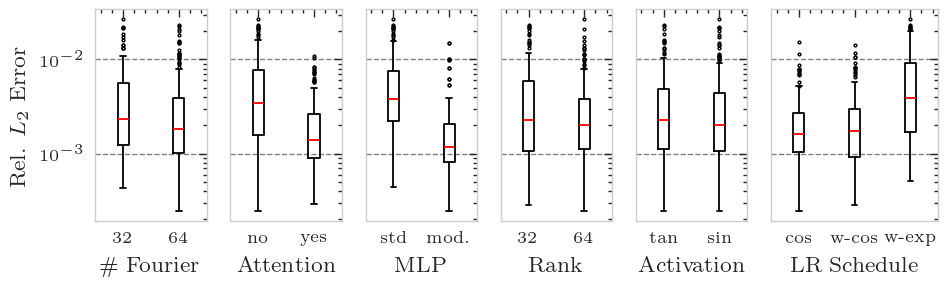

/tmp/ipykernel_56453/4139545977.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)


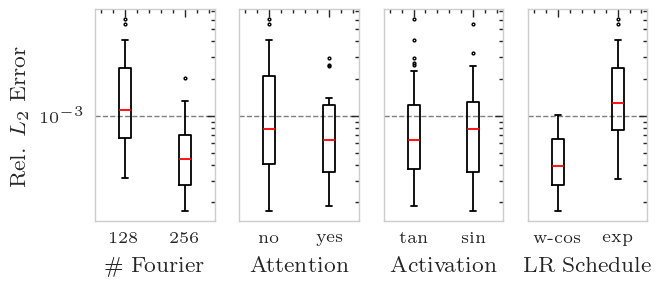

In [16]:
def plot_hyperparameter_boxplots(df, params_config, fig=None):
    n_params = len(params_config)
    page_width = get_current_config().page_width

    if fig is None:
        fig = plt.figure(figsize=(page_width, page_width * 0.3), dpi=200, constrained_layout=True)

    n_categories = [len(df[col].unique()) for col, _, _ in params_config]
    width_ratios = [n / sum(n_categories) for n in n_categories]
    grid = plt.GridSpec(1, n_params, figure=fig, wspace=0.15, width_ratios=width_ratios)

    for i, (col_name, axis_label, tick_labels) in enumerate(params_config):
        ax = plt.subplot(grid[0, i])
        sns.boxplot(data=df, x=col_name, y="l2_relative_error", ax=ax,
                    width=0.2, medianprops={'color': 'red'}, fill=False,
                    color='black', linewidth=0.65, fliersize=0.5)
        ax.set_yscale("log")
        ax.set_xlabel(axis_label)
        ax.set_ylabel(r"Rel. $L_2$ Error" if i == 0 else "")
        if i > 0:
            ax.set_yticklabels([])
        if tick_labels:
            ax.set_xticklabels(tick_labels)
    return fig

sns.set_style("whitegrid")
plt.style.use(['science', 'grid'])
page_width = get_current_config().page_width

# SPINN
spinn_params = [
    ("n_fourier_features", r"\# Fourier", None), ("SA", "Attention", ["no", "yes"]),
    ("mlp_type", "MLP", ["std", "mod."]), ("rank", "Rank", None),
    ("act", "Activation", None), ("lr_sched", "LR Schedule", None),
]
fig_spinn = plot_hyperparameter_boxplots(df_spinn, spinn_params)
plt.show()

# PINN
pinn_params = [
    ("n_fourier_features", r"\# Fourier", None), ("SA", "Attention", ["no", "yes"]),
    ("act", "Activation", None), ("lr_sched", "LR Schedule", None),
]
fig_pinn = plot_hyperparameter_boxplots(
    df_pinn, pinn_params,
    fig=plt.figure(figsize=(page_width * 9/13, page_width * 0.3), dpi=200, constrained_layout=True)
)
plt.show()

if save_fig:
    figure_folder = Path("images")
    (figure_folder / "pgf").mkdir(parents=True, exist_ok=True)
    for name, fig in [("ac_spinn_hyperparameter_boxplot", fig_spinn), ("ac_pinn_hyperparameter_boxplot", fig_pinn)]:
        fig.savefig(figure_folder / f"{name}.png", bbox_inches='tight', dpi=300)
        fig.savefig(figure_folder / "pgf" / f"{name}.pgf")

,Mean L2 Error,Std L2 Error,Iter/sec,Count
Category,,,,
Std,8.48e-03,5.84e-03,637.8,96
Std+SA,3.00e-03,2.24e-03,470.9,96
Modif.,2.62e-03,2.85e-03,472.4,96
Modif.+SA,1.13e-03,7.54e-04,354.0,96


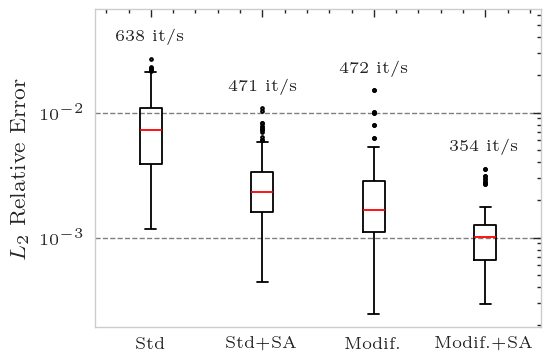

Saved LaTeX table to tables/ac_accuracy_cost_tradeoff.tex


In [24]:
category_order = ["Std", "Std+SA", "Modif.", "Modif.+SA"]
df_spinn_cat = df_spinn.copy()
df_spinn_cat["Category"] = df_spinn_cat.apply(
    lambda r: f"{'Modif.' if r['mlp_type'] == 'modified-mlp' else 'Std'}{'+SA' if r['SA'] else ''}", axis=1
)
df_spinn_cat["Category"] = pd.Categorical(df_spinn_cat["Category"], categories=category_order, ordered=True)

# Table
df_comparison = (df_spinn_cat.groupby("Category", observed=True)
    .agg({"l2_relative_error": ["mean", "std"], "iterations_per_sec": "mean", "Category": "count"})
    .droplevel(0, axis=1)
    .rename(columns={"mean": "Mean L2 Error", "std": "Std L2 Error", "count": "Count"})
)
df_comparison.columns = ["Mean L2 Error", "Std L2 Error", "Iter/sec", "Count"]
df_comparison = df_comparison.sort_values("Mean L2 Error", ascending=False)

display(df_comparison.style
    .background_gradient(subset=["Mean L2 Error"], cmap="Greens_r")
    .background_gradient(subset=["Iter/sec"], cmap="Blues")
    .format({"Mean L2 Error": "{:.2e}", "Std L2 Error": "{:.2e}", "Iter/sec": "{:.1f}"}))

# Boxplot
page_width = get_current_config().page_width
fig, ax = plt.subplots(figsize=(page_width * 0.6, page_width * 0.4), dpi=200)
sns.boxplot(data=df_spinn_cat, x="Category", y="l2_relative_error", ax=ax,
            order=category_order, width=0.2, medianprops={'color': 'red'},
            fill=False, color='black', linewidth=0.65, fliersize=0.7)
ax.set_yscale("log")
ax.set_ylabel(r"$L_2$ Relative Error")
ax.set_xlabel("")

for i, cat in enumerate(category_order):
    sub = df_spinn_cat[df_spinn_cat["Category"] == cat]
    if len(sub) > 0:
        ax.text(i, sub["l2_relative_error"].max() * 1.3, f"{sub['iterations_per_sec'].mean():.0f} it/s", ha='center', va='bottom')
ax.set_ylim(ymax=df_spinn_cat["l2_relative_error"].max() * 2.5)
plt.tight_layout()
plt.show()

if save_fig:
    fig.savefig(Path("images") / "ac_accuracy_cost_boxplot.png", bbox_inches='tight', dpi=300)
    fig.savefig(Path("images") / "pgf" / "ac_accuracy_cost_boxplot.pgf", bbox_inches='tight')
    
    df_to_save = df_comparison.drop(columns=["Count"]).reset_index()
    formatters = {"Mean L2 Error": "{:.2e}", "Std L2 Error": "{:.2e}", "Iter/sec": "{:.1f}"}
    save_df_to_latex(df_to_save, "./tables/ac_accuracy_cost_tradeoff.tex", formatters=formatters)

In [11]:
df_all = pd.concat([df_pinn, df_spinn], ignore_index=True)
hp_cols = [c for c in ["net_type", "mlp_type", "activations", "n_fourier_features", "rank", "SA", "lr_decay", "n_iter"] if c in df_all.columns]

agg_all = (df_all.groupby(hp_cols)
    .agg(mean_l2=("l2_relative_error", "mean"), std_l2=("l2_relative_error", "std"),
         iter_per_sec=("iterations_per_sec", "mean"), count=("l2_relative_error", "count"))
    .reset_index())

best_per_type = agg_all.loc[agg_all.groupby("net_type")["mean_l2"].idxmin()]

# All-SPINN: aggregate across ALL SPINN runs (all configs)
all_spinn_row = pd.DataFrame([{
    "Model": "all-SPINN",
    "Mean L2 Error": df_spinn["l2_relative_error"].mean(),
    "Std L2 Error": df_spinn["l2_relative_error"].std(),
    "Iter./s": df_spinn["iterations_per_sec"].mean(),
}])

df_best = pd.DataFrame([{
    "Model": f"best-{row['net_type']}",
    "Mean L2 Error": row["mean_l2"],
    "Std L2 Error": row["std_l2"],
    "Iter./s": row["iter_per_sec"],
} for _, row in best_per_type.sort_values("mean_l2", ascending=False).iterrows()])

df_best = pd.concat([df_best, all_spinn_row], ignore_index=True)

display(df_best.style
    .background_gradient(subset=["Mean L2 Error"], cmap="Greens_r")
    .background_gradient(subset=["Iter./s"], cmap="Blues")
    .format({"Mean L2 Error": "{:.2e}", "Std L2 Error": "{:.2e}", "Iter./s": "{:.1f}"}))

if save_fig:
    formatters = {"Mean L2 Error": "{:.2e}", "Std L2 Error": "{:.2e}", "Iter./s": "{:.1f}"}
    save_df_to_latex(df_best, "./tables/ac_best_pinn_vs_spinn.tex", formatters=formatters)

NameError: name 'pd' is not defined